In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

In [2]:
df = pd.read_csv("superstore_clean.csv", parse_dates=["Order Date", "Ship Date"])

In [3]:
print(df.shape)
print(df.head())

(9994, 25)
   Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
1       2  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
2       3  CA-2016-138688 2016-06-12 2016-06-16    Second Class    DV-13045   
3       4  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   
4       5  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Sub-Category                                       Product Name     Sales  \
0    Bookcases

In [4]:
sns.set_theme(style = "whitegrid", palette = "Blues_d")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"

In [5]:
region = df.groupby("Region")[["Sales", "Profit"]].sum().sort_values("Sales", ascending = False)
print(region)

               Sales       Profit
Region                           
West     725457.8245  108418.4489
East     678781.2400   91522.7800
Central  501239.8908   39706.3625
South    391721.9050   46749.4303


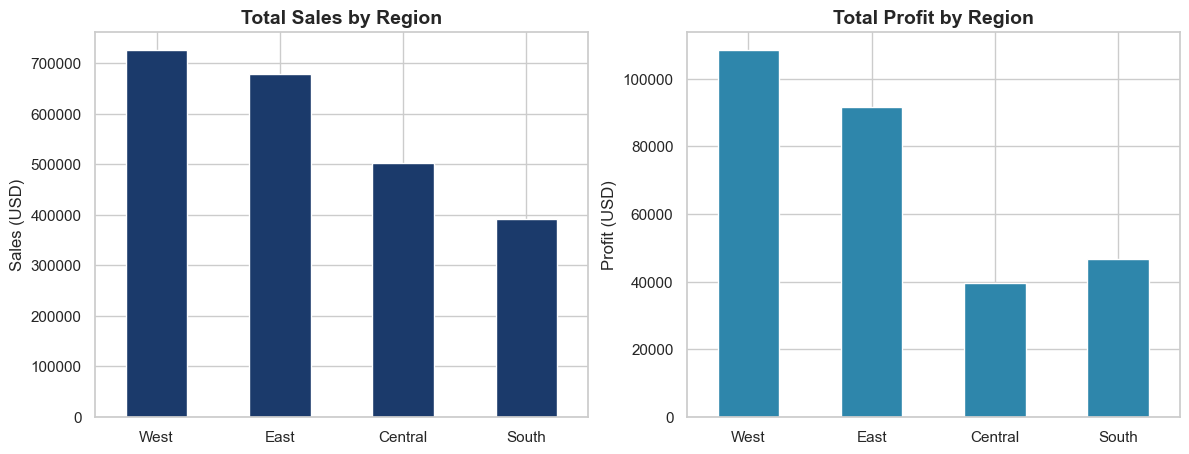

In [6]:
fig, axes = plt.subplots(1, 2, figsize = (14, 5))

region["Sales"].plot(kind = "bar", ax = axes[0], color = "#1B3A6B", edgecolor = "white")
axes[0].set_title("Total Sales by Region")
axes[0].set_xlabel("")
axes[0].set_ylabel("Sales (USD)")
axes[0].tick_params(axis = "x", rotation = 0)

region["Profit"].plot(kind = "bar", ax = axes[1], color = "#2E86AB", edgecolor = "white")
axes[1].set_title("Total Profit by Region")
axes[1].set_xlabel("")
axes[1].set_ylabel("Profit (USD)")
axes[1].tick_params(axis = "x", rotation = 0)

plt.tight_layout
plt.savefig("region_sales_profit.png", dpi = 150)
plt.show()

In [9]:
category = df.groupby("Category")[["Sales", "Profit"]].sum().sort_values("Profit", ascending = False)

In [11]:
category["Profit Margin %"] = (category["Profit"] / category ["Sales"] * 100).round(2)
print(category)

                       Sales       Profit  Profit Margin %
Category                                                  
Technology       836154.0330  145454.9481            17.40
Office Supplies  719047.0320  122490.8008            17.04
Furniture        741999.7953   18451.2728             2.49


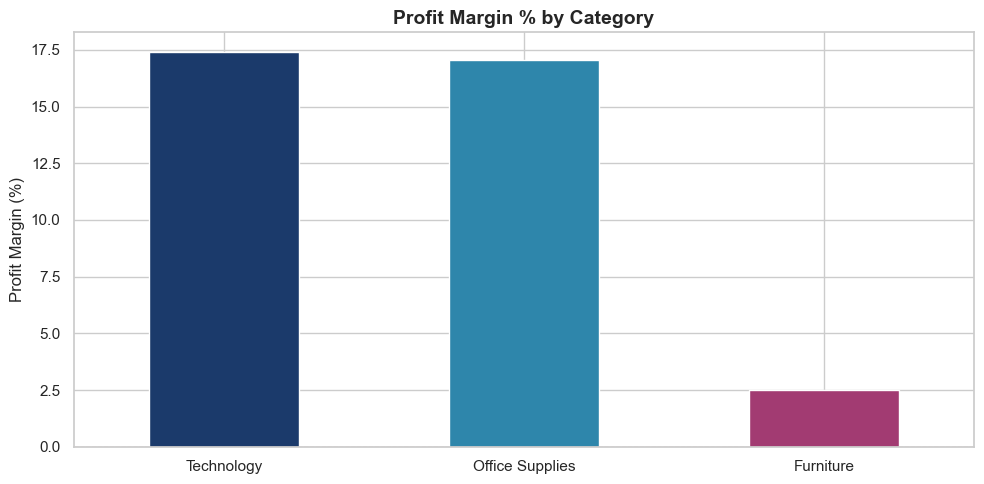

In [12]:
fig, ax = plt.subplots(figsize = (10, 5))
category["Profit Margin %"].plot(kind = "bar", ax = ax, color = ["#1B3A6B", "#2E86AB", "#A23B72"], edgecolor = "white")
ax.set_title("Profit Margin % by Category")
ax.set_xlabel("")
ax.set_ylabel("Profit Margin (%)")
ax.tick_params(axis = "x", rotation = 0)
ax.axhline(0, color = "red", linewidth = 0.8, linestyle = "--")

plt.tight_layout()
plt.savefig("category_margin.png", dpi = 150)
plt.show()